# Addis Ababa Ride Demand Forecasting
## 03 — Visualization Pack (Deliverable C)

Produces the 12 required figures in `figures/` (PNG, 150 dpi, ≥1200 px wide) and `figures/figure_captions.md`.

* Figures 01–09 use the cleaned data from notebook 01 (and the same baselines as notebook 02).
* Figures 10–12 need model results. They are drawn from the files that `04_modeling_and_evaluation.ipynb` writes to `reports/`
  (`model_results.csv`, `val_predictions.csv`, `feature_importance.csv`). **Run notebook 04 first, then re-run this notebook.**

Style: one consistent theme, colour-blind-safe Okabe–Ito palette, titles, axis labels with units, legends, bar charts starting at zero.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(42)

ROOT = Path.cwd().parent if (Path.cwd().parent / "data").exists() else Path.cwd()
RAW, PROC, FIG, REP = ROOT / "data" / "raw", ROOT / "data" / "processed", ROOT / "figures", ROOT / "reports"
FIG.mkdir(exist_ok=True)

OKABE = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]
sns.set_theme(style="whitegrid", palette=OKABE, font_scale=1.15)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "axes.titlesize": 14, "figure.titlesize": 16})
SEQ = "cividis"   # colour-blind-safe sequential map

def save(fig, name):
    fig.savefig(FIG / name)
    plt.show()
    print("saved", name)

m = pd.read_csv(PROC / "master_train.csv", parse_dates=["datetime"])
ev = pd.read_csv(PROC / "events_processed.csv", parse_dates=["start", "end"])
ev["zones"] = ev["zones"].fillna("").str.split("|")
weather = pd.read_csv(PROC / "weather_hourly_processed.csv", parse_dates=["datetime"])
m["date"] = m["datetime"].dt.normalize()

ZONE_TYPE = {"Arat Kilo": "business/CBD", "Kazanchis": "business/CBD", "Piassa": "business/CBD",
             "Ayat": "residential", "CMC": "residential", "Gerji": "residential", "Kolfe": "residential",
             "Sarbet": "residential", "Lideta": "transport hub", "Megenagna": "transport hub",
             "Merkato": "market", "Bole": "nightlife/airport"}
TYPES = ["business/CBD", "transport hub", "residential", "market", "nightlife/airport"]
TYPE_COL = dict(zip(TYPES, [OKABE[4], OKABE[0], OKABE[2], OKABE[5], OKABE[6]]))
m["zone_type"] = m["zone"].map(ZONE_TYPE)

# Same "ordinary-hour" baseline as notebook 02: zone x weekday x hour shape x zone growth trend
ordinary = (m.rain_mm == 0) & (m.event_in_window == 0) & (m.is_public_holiday == 0) & (m.is_school_break == 0)
K = ["zone", "day_of_week", "hour"]
m = m.merge(m[ordinary].groupby(K)["trips"].mean().rename("shape"), on=K, how="left")
lvl = {}
for z, g in m[ordinary].groupby("zone"):
    d = g.groupby("date").agg(t=("trips", "sum"), s=("shape", "sum"))
    lvl[z] = (np.polyfit((d.index - d.index.min()).days, d.t / d.s, 1), d.index.min())
m["baseline"] = m["shape"] * [np.polyval(lvl[z][0], (d - lvl[z][1]).days) for z, d in zip(m.zone, m.date)]
print(m.shape)

(82979, 41)


## fig01 — Gaps and missingness

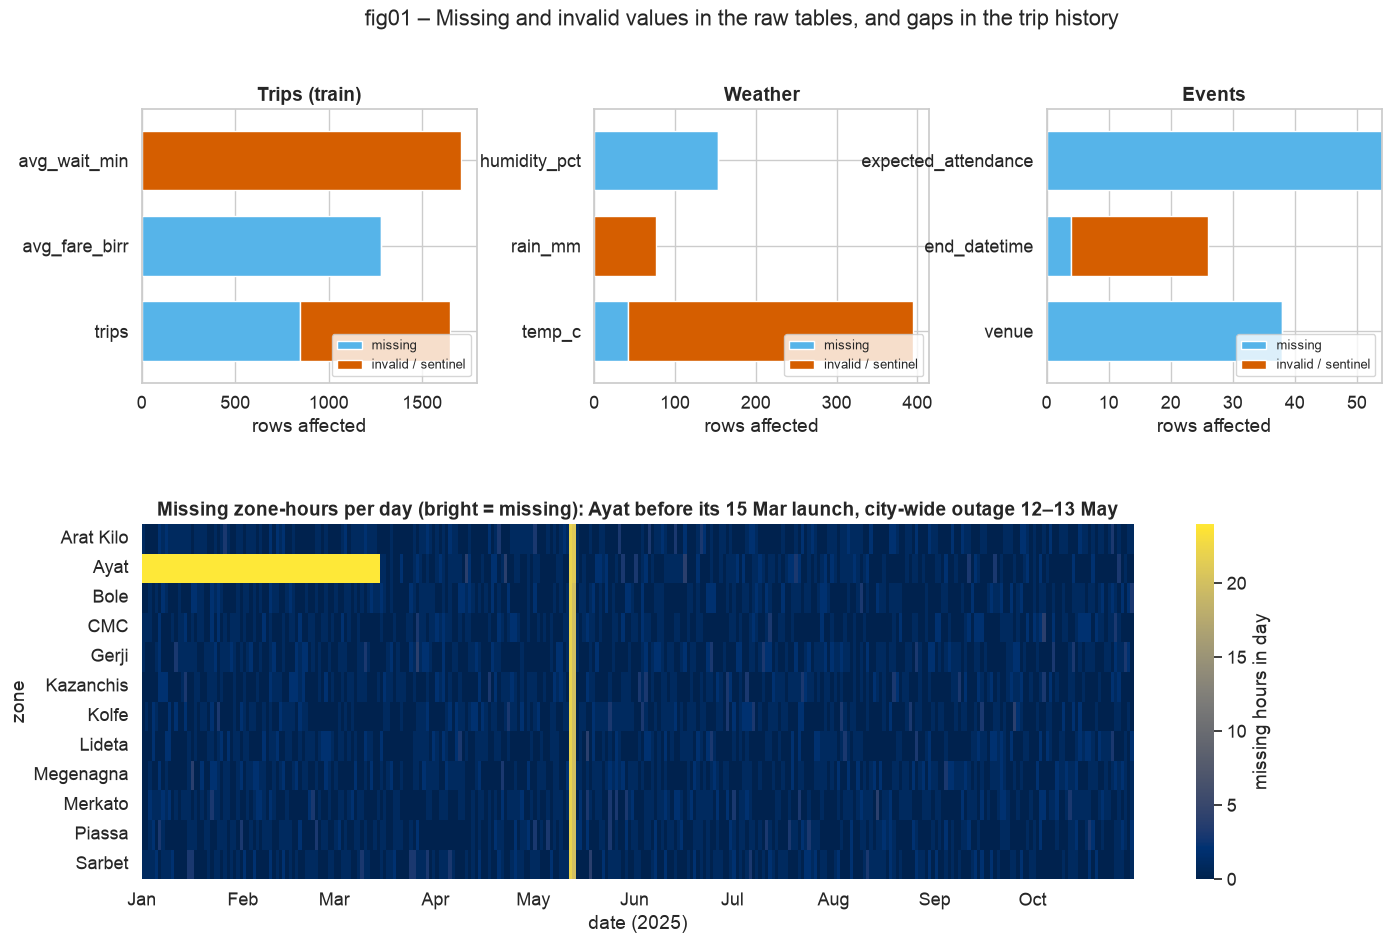

saved fig01_gaps_and_missingness.png


In [2]:
tr = pd.read_csv(RAW / "ride_demand_train.csv"); wr = pd.read_csv(RAW / "weather_hourly.csv")
er = pd.read_csv(RAW / "events_calendar.csv")
def invalid_counts(df, rules):
    out = {}
    for c in df.columns:
        miss = df[c].isna().sum()
        bad = int(rules[c](df[c]).sum()) if c in rules else 0
        out[c] = (miss, bad)
    return pd.DataFrame(out, index=["missing", "invalid / sentinel"]).T
tables = {
    "Trips (train)": invalid_counts(tr, {"trips": lambda s: s.eq(-1) | (s > 4 * tr.active_drivers),
                                         "avg_wait_min": lambda s: s < 0}),
    "Weather": invalid_counts(wr, {"rain_mm": lambda s: s.eq(-9999), "temp_c": lambda s: s > 40}),
    "Events": invalid_counts(er, {"end_datetime": lambda s: pd.Series(False, index=s.index)}),
}
# events: end earlier than start is "invalid" (parsed loosely just for the count)
st = pd.to_datetime(er.start_datetime, format="mixed", dayfirst=True, errors="coerce")
en = pd.to_datetime(er.end_datetime, format="mixed", dayfirst=True, errors="coerce")
tables["Events"].loc["end_datetime", "invalid / sentinel"] = int((en < st).sum())

# timeline of missing hours per zone per day
hours = pd.date_range("2025-01-01", "2025-10-31 23:00", freq="h")
zones = sorted(m.zone.unique())
present = m.groupby(["zone", "date"]).size().unstack(fill_value=0).reindex(index=zones,
          columns=pd.date_range("2025-01-01", "2025-10-31"), fill_value=0)
missing_day = 24 - present

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.3], hspace=0.45, wspace=0.35)
for i, (name, t) in enumerate(tables.items()):
    ax = fig.add_subplot(gs[0, i])
    t = t[(t.sum(axis=1) > 0)] if (t.sum(axis=1) > 0).any() else t
    t.plot.barh(stacked=True, ax=ax, color=[OKABE[1], OKABE[5]], width=0.7)
    ax.set_title(name); ax.set_xlabel("rows affected"); ax.set_ylabel("")
    ax.legend(fontsize=9, loc="lower right")
ax = fig.add_subplot(gs[1, :])
sns.heatmap(missing_day, ax=ax, cmap=SEQ, cbar_kws={"label": "missing hours in day"}, xticklabels=False, vmin=0, vmax=24)
ticks = [i for i, d in enumerate(missing_day.columns) if d.day == 1]
ax.set_xticks(ticks); ax.set_xticklabels([missing_day.columns[i].strftime("%b") for i in ticks], rotation=0)
ax.set_title("Missing zone-hours per day (bright = missing): Ayat before its 15 Mar launch, city-wide outage 12–13 May")
ax.set_xlabel("date (2025)"); ax.set_ylabel("zone")
fig.suptitle("fig01 – Missing and invalid values in the raw tables, and gaps in the trip history")
save(fig, "fig01_gaps_and_missingness.png")

## fig02 — Before vs after cleaning

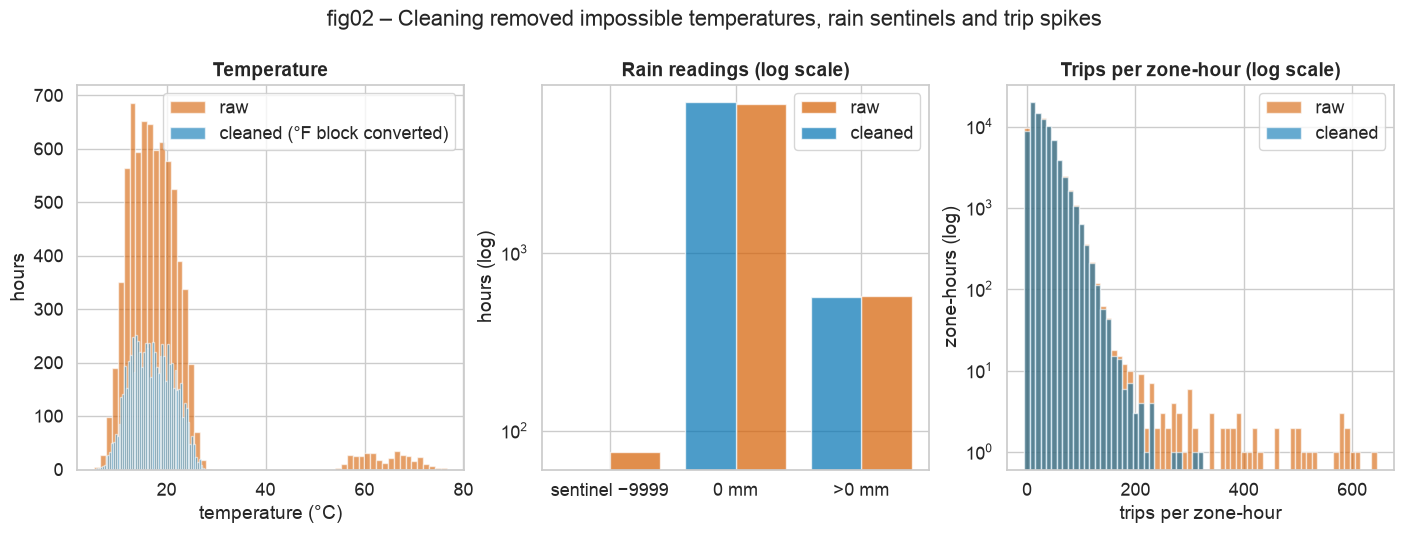

saved fig02_before_after_cleaning.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ax = axes[0]
ax.hist(wr.temp_c.dropna(), bins=60, alpha=0.6, label="raw", color=OKABE[5])
ax.hist(weather.temp_c, bins=60, alpha=0.6, label="cleaned (°F block converted)", color=OKABE[4])
ax.set_title("Temperature"); ax.set_xlabel("temperature (°C)"); ax.set_ylabel("hours"); ax.legend()
ax = axes[1]
r = wr.rain_mm
ax.bar(["sentinel −9999", "0 mm", ">0 mm"], [(r == -9999).sum(), (r == 0).sum(), (r > 0).sum()],
       color=OKABE[5], alpha=0.7, label="raw", width=0.4, align="edge")
c = weather.rain_mm
ax.bar(["sentinel −9999", "0 mm", ">0 mm"], [0, (c == 0).sum(), (c > 0).sum()],
       color=OKABE[4], alpha=0.7, label="cleaned", width=-0.4, align="edge")
ax.set_yscale("log"); ax.set_title("Rain readings (log scale)"); ax.set_ylabel("hours (log)"); ax.legend()
ax = axes[2]
bins = np.arange(-5, 650, 10)
ax.hist(tr.trips.dropna(), bins=bins, alpha=0.6, label="raw", color=OKABE[5])
ax.hist(m.trips, bins=bins, alpha=0.6, label="cleaned", color=OKABE[4])
ax.set_yscale("log"); ax.set_title("Trips per zone-hour (log scale)")
ax.set_xlabel("trips per zone-hour"); ax.set_ylabel("zone-hours (log)"); ax.legend()
fig.suptitle("fig02 – Cleaning removed impossible temperatures, rain sentinels and trip spikes", y=1.03)
save(fig, "fig02_before_after_cleaning.png")

## fig03 — Demand trend with holidays

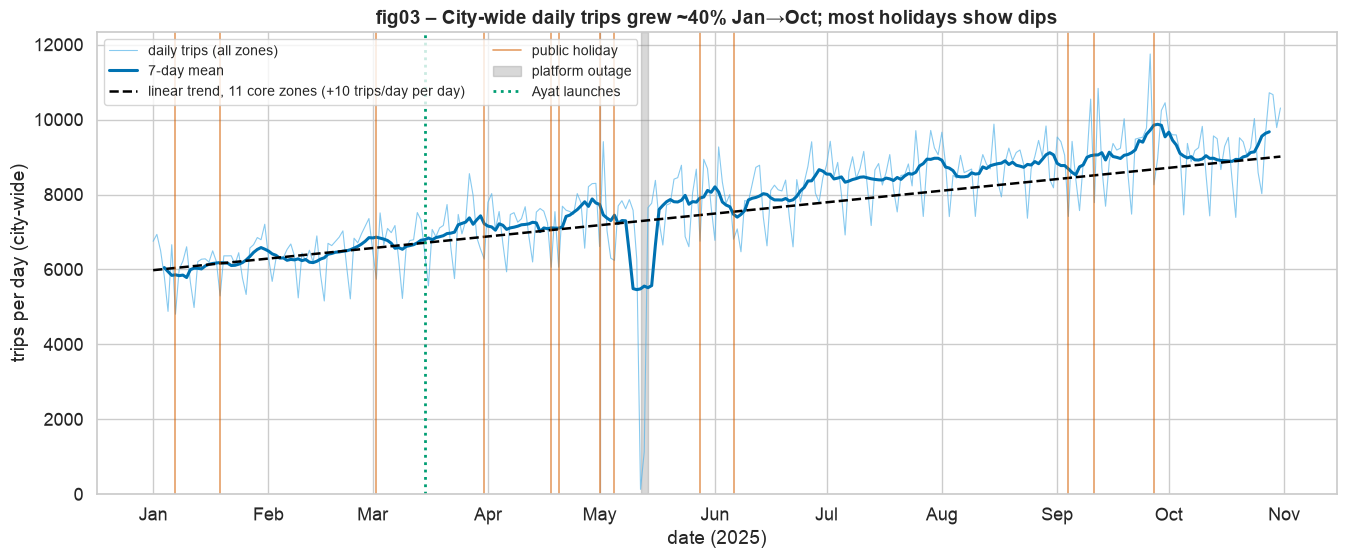

saved fig03_demand_trend_with_holidays.png


In [4]:
daily = m.groupby("date")["trips"].sum()
daily_core = m[m.zone != "Ayat"].groupby("date")["trips"].sum()
n = m.groupby("date").size()
okd = n >= 0.9 * n.median()
x = (daily_core[okd].index - daily_core.index.min()).days
fit = np.polyfit(x, daily_core[okd].values, 1)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily.index, daily, color=OKABE[1], lw=0.8, alpha=0.7, label="daily trips (all zones)")
ax.plot(daily.index, daily.rolling(7, center=True).mean(), color=OKABE[4], lw=2.2, label="7-day mean")
ax.plot(daily_core.index, np.polyval(fit, (daily_core.index - daily_core.index.min()).days),
        "--", color=OKABE[7], lw=1.8, label=f"linear trend, 11 core zones (+{fit[0]:.0f} trips/day per day)")
hol = ev[(ev.event_type == "public_holiday") & (ev.status != "cancelled")]
for i, (_, h) in enumerate(hol.iterrows()):
    ax.axvline(h.start.normalize(), color=OKABE[5], alpha=0.6, lw=1.2, label="public holiday" if i == 0 else None)
ax.axvspan(pd.Timestamp("2025-05-12"), pd.Timestamp("2025-05-14"), color="grey", alpha=0.3, label="platform outage")
ax.axvline(pd.Timestamp("2025-03-15"), color=OKABE[2], ls=":", lw=2, label="Ayat launches")
ax.set_ylim(0); ax.set_xlabel("date (2025)"); ax.set_ylabel("trips per day (city-wide)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_title("fig03 – City-wide daily trips grew ~40% Jan→Oct; most holidays show dips")
ax.legend(loc="upper left", fontsize=10, ncol=2)
save(fig, "fig03_demand_trend_with_holidays.png")

## fig04 — Hour × weekday heatmap

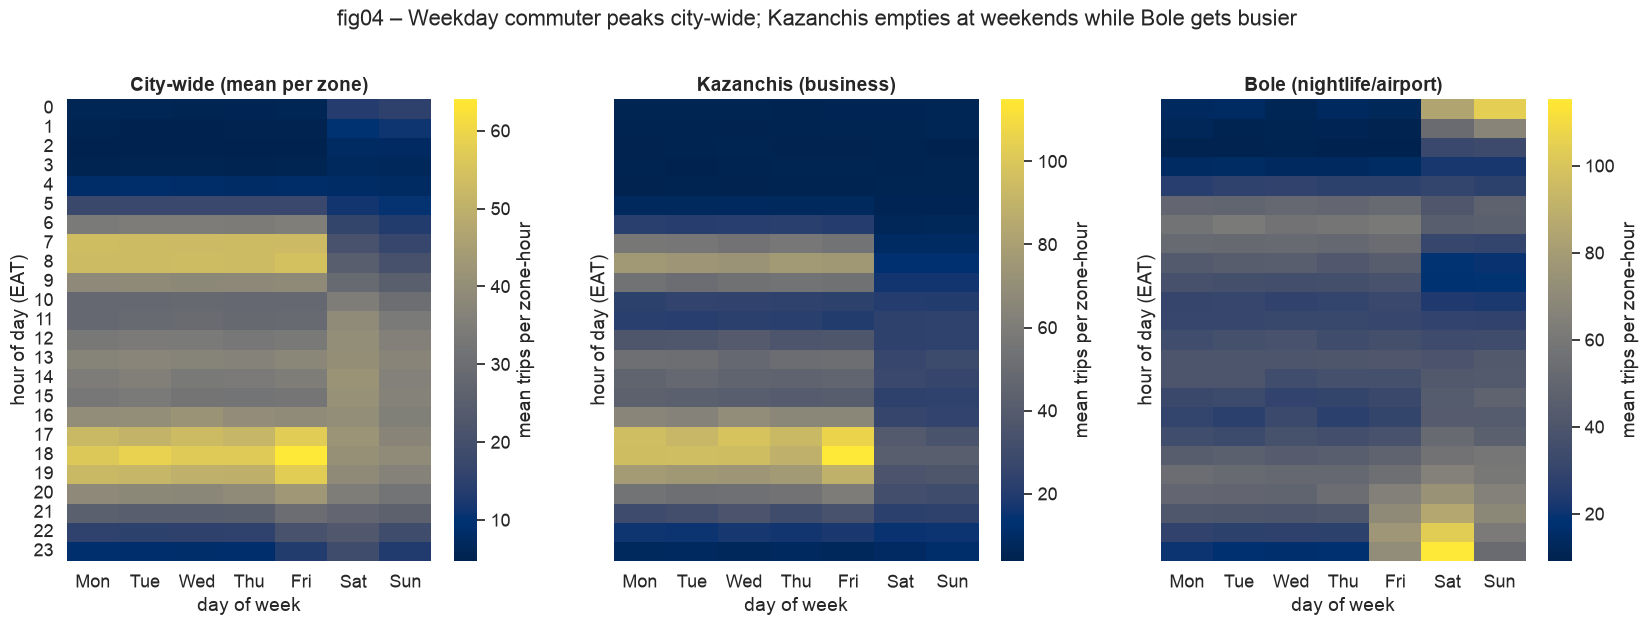

saved fig04_hour_by_weekday_heatmap.png


In [5]:
dows = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, (title, sub) in zip(axes, [("City-wide (mean per zone)", m), ("Kazanchis (business)", m[m.zone == "Kazanchis"]),
                                   ("Bole (nightlife/airport)", m[m.zone == "Bole"])]):
    p = sub[sub.is_public_holiday == 0].pivot_table(index="hour", columns="day_of_week", values="trips", aggfunc="mean")
    p.columns = dows
    sns.heatmap(p, ax=ax, cmap=SEQ, cbar_kws={"label": "mean trips per zone-hour"})
    ax.set_title(title); ax.set_xlabel("day of week"); ax.set_ylabel("hour of day (EAT)")
fig.suptitle("fig04 – Weekday commuter peaks city-wide; Kazanchis empties at weekends while Bole gets busier", y=1.03)
save(fig, "fig04_hour_by_weekday_heatmap.png")

## fig05 — Zone-type profiles

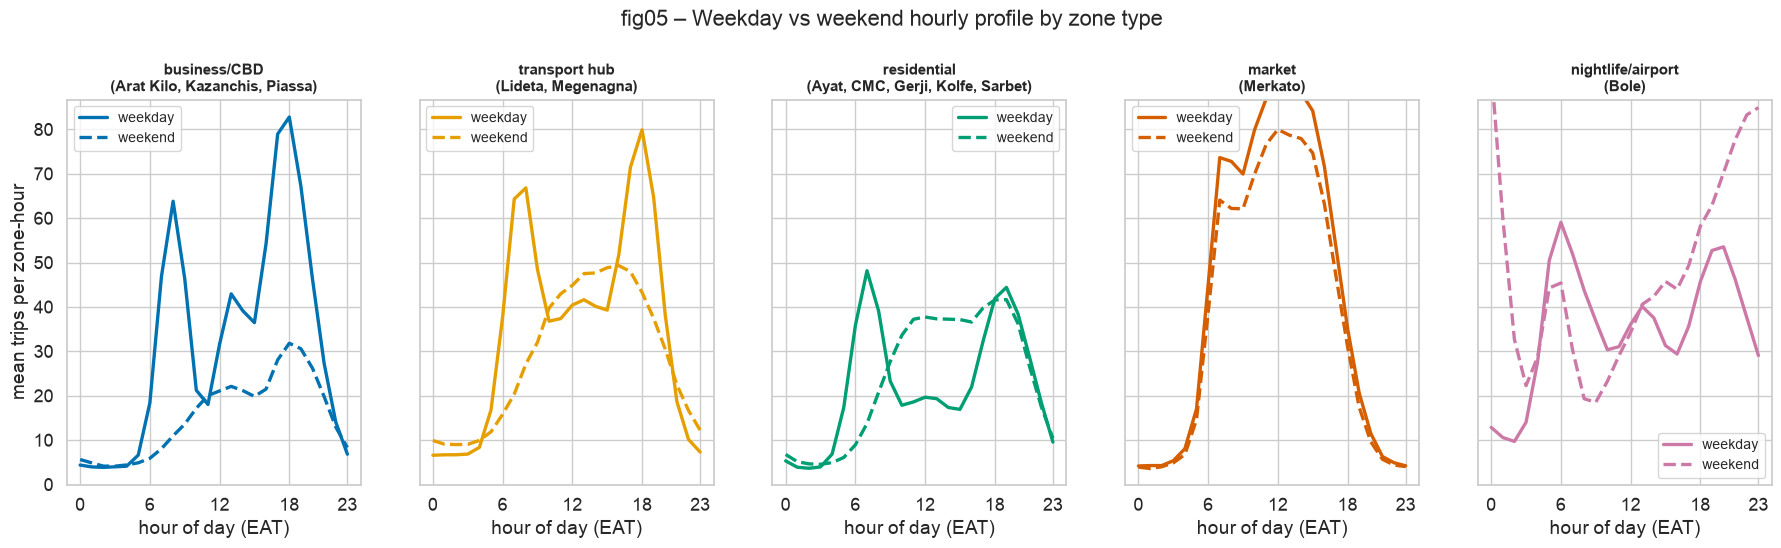

saved fig05_zone_profiles.png


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
x = m[m.is_public_holiday == 0]
for ax, t in zip(axes, TYPES):
    s = x[x.zone_type == t]
    for wkend, ls, lab in [(0, "-", "weekday"), (1, "--", "weekend")]:
        prof = s[s.is_weekend == wkend].groupby("hour")["trips"].mean()
        ax.plot(prof.index, prof.values, ls, color=TYPE_COL[t], lw=2.4, label=lab)
    ax.set_title(f"{t}\n({', '.join(sorted(z for z, v in ZONE_TYPE.items() if v == t))})", fontsize=11)
    ax.set_xlabel("hour of day (EAT)"); ax.set_xticks([0, 6, 12, 18, 23]); ax.set_ylim(0)
    ax.legend(fontsize=10)
axes[0].set_ylabel("mean trips per zone-hour")
fig.suptitle("fig05 – Weekday vs weekend hourly profile by zone type", y=1.06)
save(fig, "fig05_zone_profiles.png")

## fig06 — Weather time-zone check

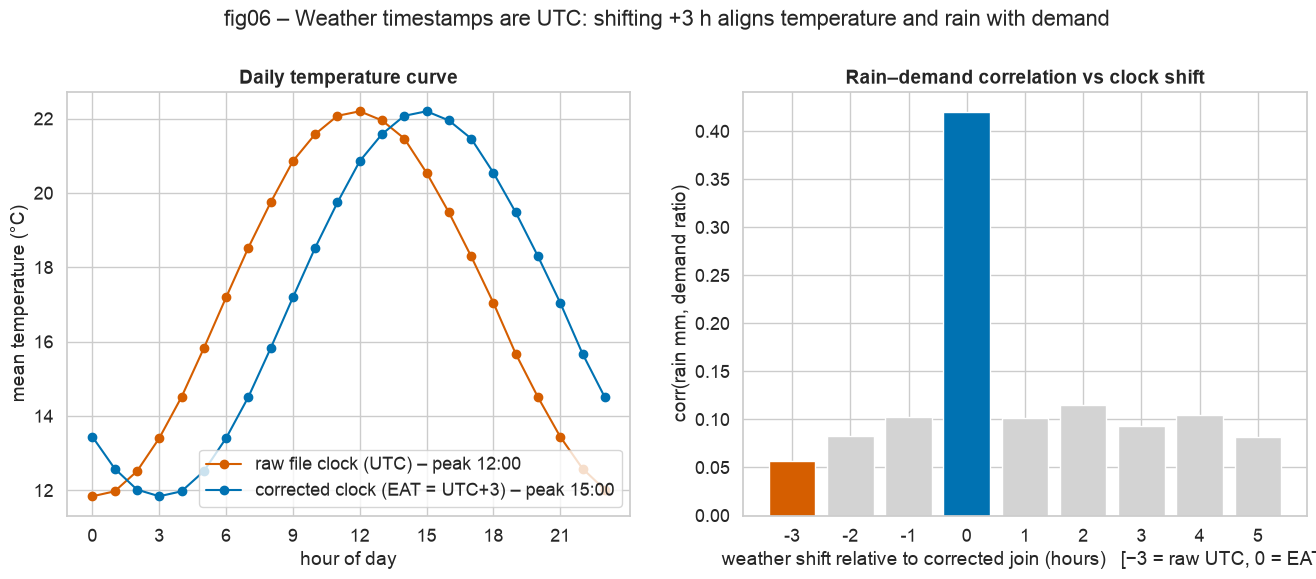

saved fig06_weather_timezone_check.png


In [7]:
obs = weather[weather.data_type == "observed"]
eat = obs.groupby(obs.datetime.dt.hour)["temp_c"].mean()
raw = obs.groupby((obs.datetime - pd.Timedelta(hours=3)).dt.hour)["temp_c"].mean()

city = m.groupby("datetime").agg(trips=("trips", "sum"), baseline=("baseline", "sum"))
city["ratio"] = city.trips / city.baseline
rain = weather.set_index("datetime")["rain_mm"]
shifts = list(range(-3, 6)); corrs = []
for k in shifts:
    r2 = rain.copy(); r2.index = r2.index + pd.Timedelta(hours=k)
    j = city.join(r2, how="inner"); corrs.append(j.ratio.corr(j.rain_mm))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
ax = axes[0]
ax.plot(raw.index, raw.values, "o-", color=OKABE[5], label=f"raw file clock (UTC) – peak {raw.idxmax()}:00")
ax.plot(eat.index, eat.values, "o-", color=OKABE[4], label=f"corrected clock (EAT = UTC+3) – peak {eat.idxmax()}:00")
ax.set_xlabel("hour of day"); ax.set_ylabel("mean temperature (°C)"); ax.set_xticks(range(0, 24, 3))
ax.set_title("Daily temperature curve"); ax.legend()
ax = axes[1]
cols = [OKABE[4] if k == 0 else (OKABE[5] if k == -3 else "lightgrey") for k in shifts]
ax.bar([str(k) for k in shifts], corrs, color=cols)
ax.set_xlabel("weather shift relative to corrected join (hours)   [−3 = raw UTC, 0 = EAT]")
ax.set_ylabel("corr(rain mm, demand ratio)"); ax.set_ylim(0)
ax.set_title("Rain–demand correlation vs clock shift")
fig.suptitle("fig06 – Weather timestamps are UTC: shifting +3 h aligns temperature and rain with demand", y=1.03)
save(fig, "fig06_weather_timezone_check.png")

## fig07 — Rain effect by zone type

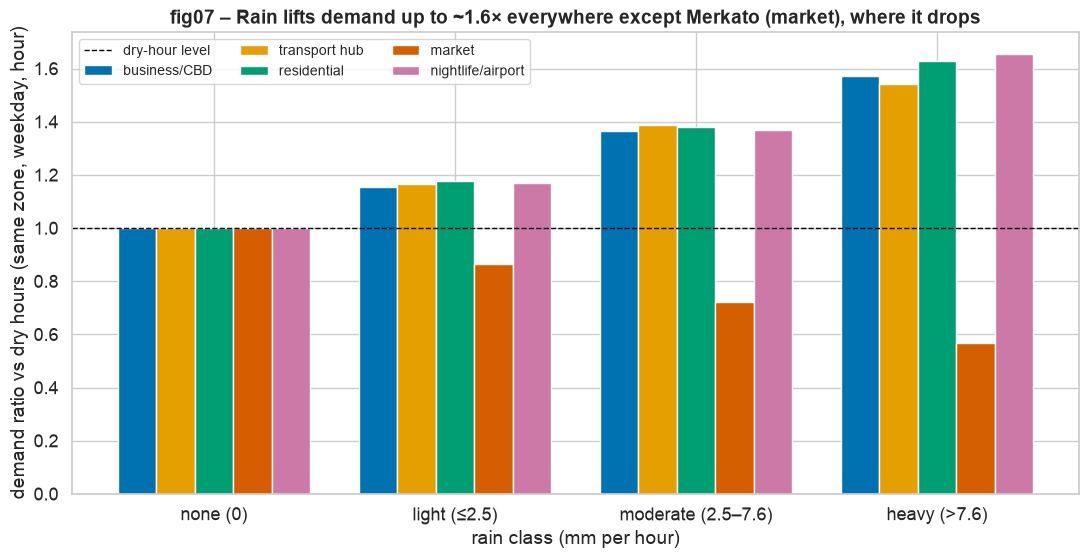

saved fig07_rain_effect.png


In [8]:
order = ["none", "light", "moderate", "heavy"]
d = m[(m.event_in_window == 0) & (m.is_public_holiday == 0)]
g = d.groupby(["zone_type", "rain_class"])[["trips", "baseline"]].sum()
ratio = (g.trips / g.baseline).unstack()[order]
ratio = ratio.div(ratio["none"], axis=0).reindex(TYPES)
fig, ax = plt.subplots(figsize=(13, 6))
w = 0.16
for i, t in enumerate(TYPES):
    ax.bar(np.arange(4) + (i - 2) * w, ratio.loc[t], w, color=TYPE_COL[t], label=t)
ax.axhline(1, color="black", lw=1, ls="--", label="dry-hour level")
ax.set_xticks(range(4)); ax.set_xticklabels(["none (0)", "light (≤2.5)", "moderate (2.5–7.6)", "heavy (>7.6)"])
ax.set_xlabel("rain class (mm per hour)"); ax.set_ylabel("demand ratio vs dry hours (same zone, weekday, hour)")
ax.set_ylim(0); ax.legend(ncol=3, fontsize=10)
ax.set_title("fig07 – Rain lifts demand up to ~1.6× everywhere except Merkato (market), where it drops")
save(fig, "fig07_rain_effect.png")

## fig08 — Event study around start time

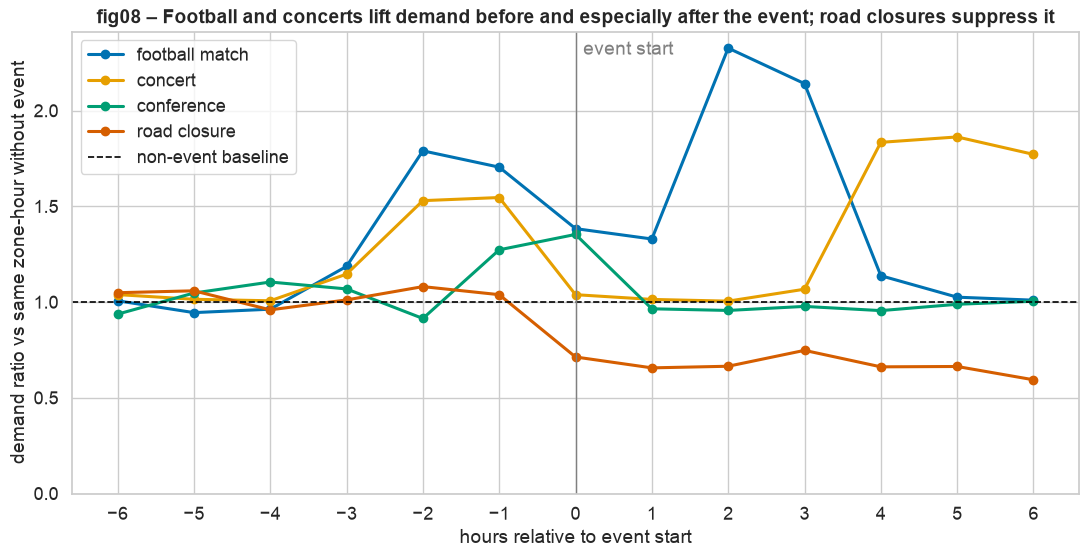

saved fig08_event_study.png


In [9]:
def event_curve(etype, rel=range(-6, 7)):
    rows = []
    for _, e in ev[(ev.event_type == etype) & (ev.status != "cancelled")].iterrows():
        s = e.start.floor("h")
        for z in e.zones:
            sub = m[(m.zone == z) & m.datetime.between(s - pd.Timedelta(hours=6), s + pd.Timedelta(hours=6))]
            for _, r in sub.iterrows():
                rows.append(((r.datetime - s) / pd.Timedelta(hours=1), r.trips, r.baseline))
    df = pd.DataFrame(rows, columns=["rel_h", "trips", "baseline"])
    g = df.groupby("rel_h")[["trips", "baseline"]].sum()
    return g.trips / g.baseline

fig, ax = plt.subplots(figsize=(13, 6))
for et, c in [("football_match", OKABE[4]), ("concert", OKABE[0]), ("conference", OKABE[2]), ("road_closure", OKABE[5])]:
    cur = event_curve(et)
    ax.plot(cur.index, cur.values, "o-", color=c, lw=2.2, label=et.replace("_", " "))
ax.axhline(1, color="black", ls="--", lw=1.2, label="non-event baseline")
ax.axvline(0, color="grey", lw=1); ax.text(0.1, ax.get_ylim()[1] * 0.95, "event start", color="grey")
ax.set_xlabel("hours relative to event start"); ax.set_ylabel("demand ratio vs same zone-hour without event")
ax.set_xticks(range(-6, 7)); ax.set_ylim(0); ax.legend()
ax.set_title("fig08 – Football and concerts lift demand before and especially after the event; road closures suppress it")
save(fig, "fig08_event_study.png")

## fig09 — Holiday effects

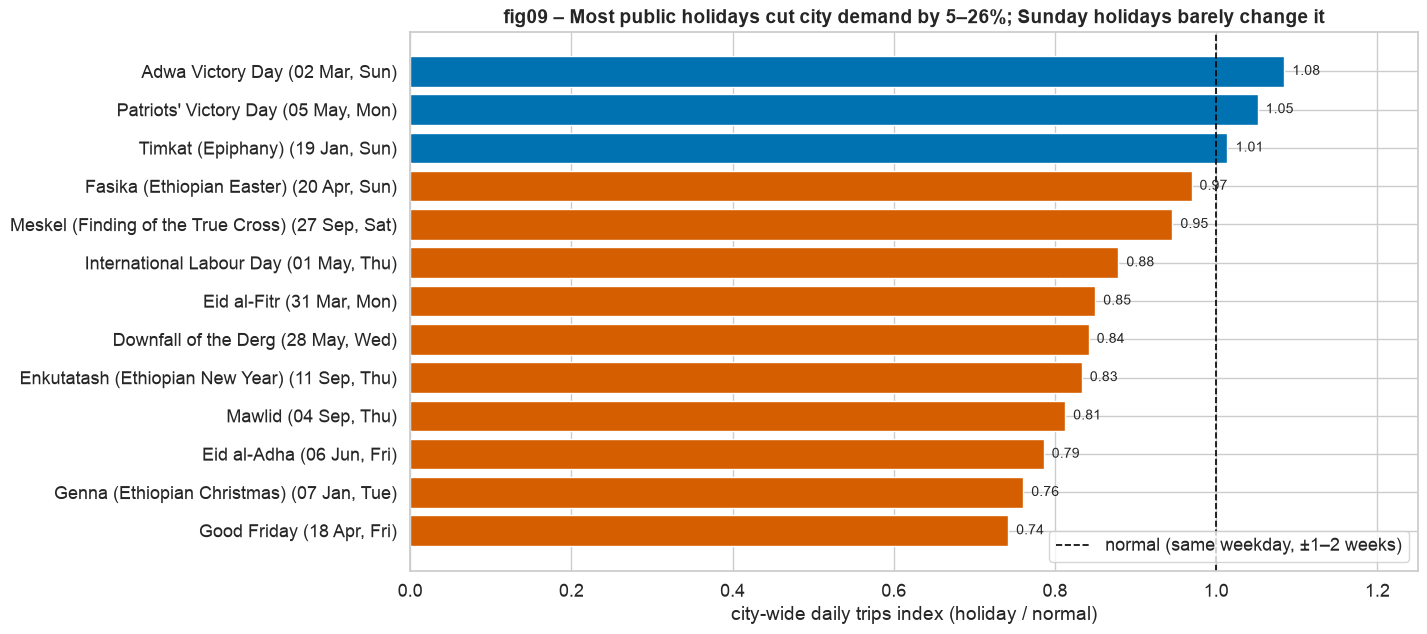

saved fig09_holiday_effects.png


In [10]:
city_d = m.groupby("date")["trips"].sum()
hol = ev[(ev.event_type == "public_holiday") & (ev.status != "cancelled")]
rows = []
hol_days = {h.start.normalize() for _, h in hol.iterrows()}
for _, h in hol.iterrows():
    dday = h.start.normalize()
    if dday not in city_d.index: continue
    refs = [dday + pd.Timedelta(weeks=w) for w in (-2, -1, 1, 2)]
    refs = [r for r in refs if r in city_d.index and r not in hol_days]
    rows.append((f"{h.event_name} ({dday:%d %b}, {dday:%a})", city_d[dday] / city_d[refs].mean()))
hi = pd.DataFrame(rows, columns=["holiday", "index"]).drop_duplicates("holiday").sort_values("index")
fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(hi.holiday, hi["index"], color=[OKABE[5] if v < 1 else OKABE[4] for v in hi["index"]])
ax.axvline(1, color="black", ls="--", lw=1.2, label="normal (same weekday, ±1–2 weeks)")
for y, v in enumerate(hi["index"]): ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=10)
ax.set_xlim(0, 1.25); ax.set_xlabel("city-wide daily trips index (holiday / normal)"); ax.legend(loc="lower right")
ax.set_title("fig09 – Most public holidays cut city demand by 5–26%; Sunday holidays barely change it")
save(fig, "fig09_holiday_effects.png")

## fig10–fig12 — Model figures (need notebook 04 outputs)

Expected files written by notebook 04:

| file | columns |
|---|---|
| `reports/model_results.csv` | `model, rmse, mae, rmse_std` (rmse_std = rolling-origin std, NaN if not computed), `is_baseline` |
| `reports/val_predictions.csv` | `zone, datetime, trips, predicted` for the validation fortnight |
| `reports/feature_importance.csv` | `feature, importance, importance_std, group` (group ∈ calendar/weather/event/lag) |

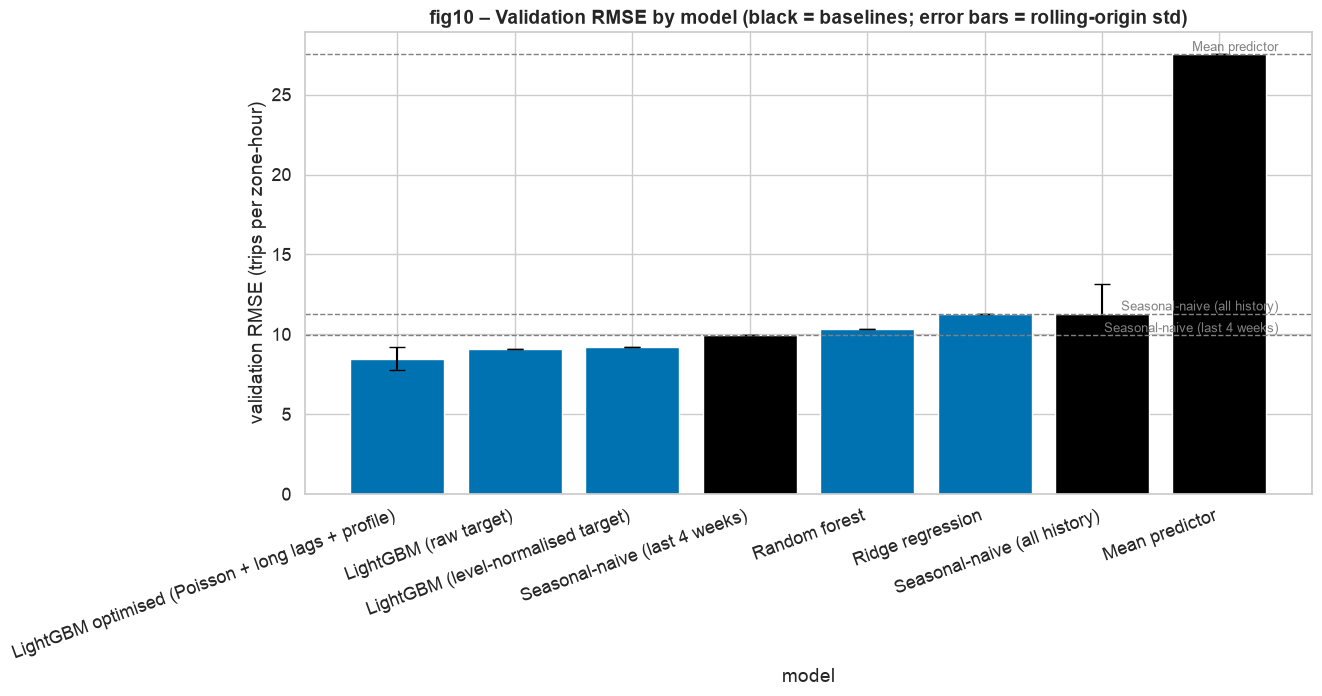

saved fig10_model_comparison.png


In [11]:
def need(fname):
    p = REP / fname
    if not p.exists():
        print(f"⚠ {fname} not found – run notebook 04 first, then re-run this cell.")
        return None
    return pd.read_csv(p)

res = need("model_results.csv")
if res is not None:
    res = res.sort_values("rmse")
    fig, ax = plt.subplots(figsize=(13, 6))
    colors = [OKABE[7] if b else OKABE[4] for b in res.is_baseline]
    ax.bar(res.model, res.rmse, yerr=res.rmse_std.fillna(0), capsize=6, color=colors)
    for _, r in res[res.is_baseline.astype(bool)].iterrows():
        ax.axhline(r.rmse, ls="--", lw=1, color="grey")
        ax.text(len(res) - 0.5, r.rmse, f" {r.model}", va="bottom", ha="right", fontsize=9, color="grey")
    ax.set_ylim(0); ax.set_ylabel("validation RMSE (trips per zone-hour)"); ax.set_xlabel("model")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    ax.set_title("fig10 – Validation RMSE by model (black = baselines; error bars = rolling-origin std)")
    save(fig, "fig10_model_comparison.png")

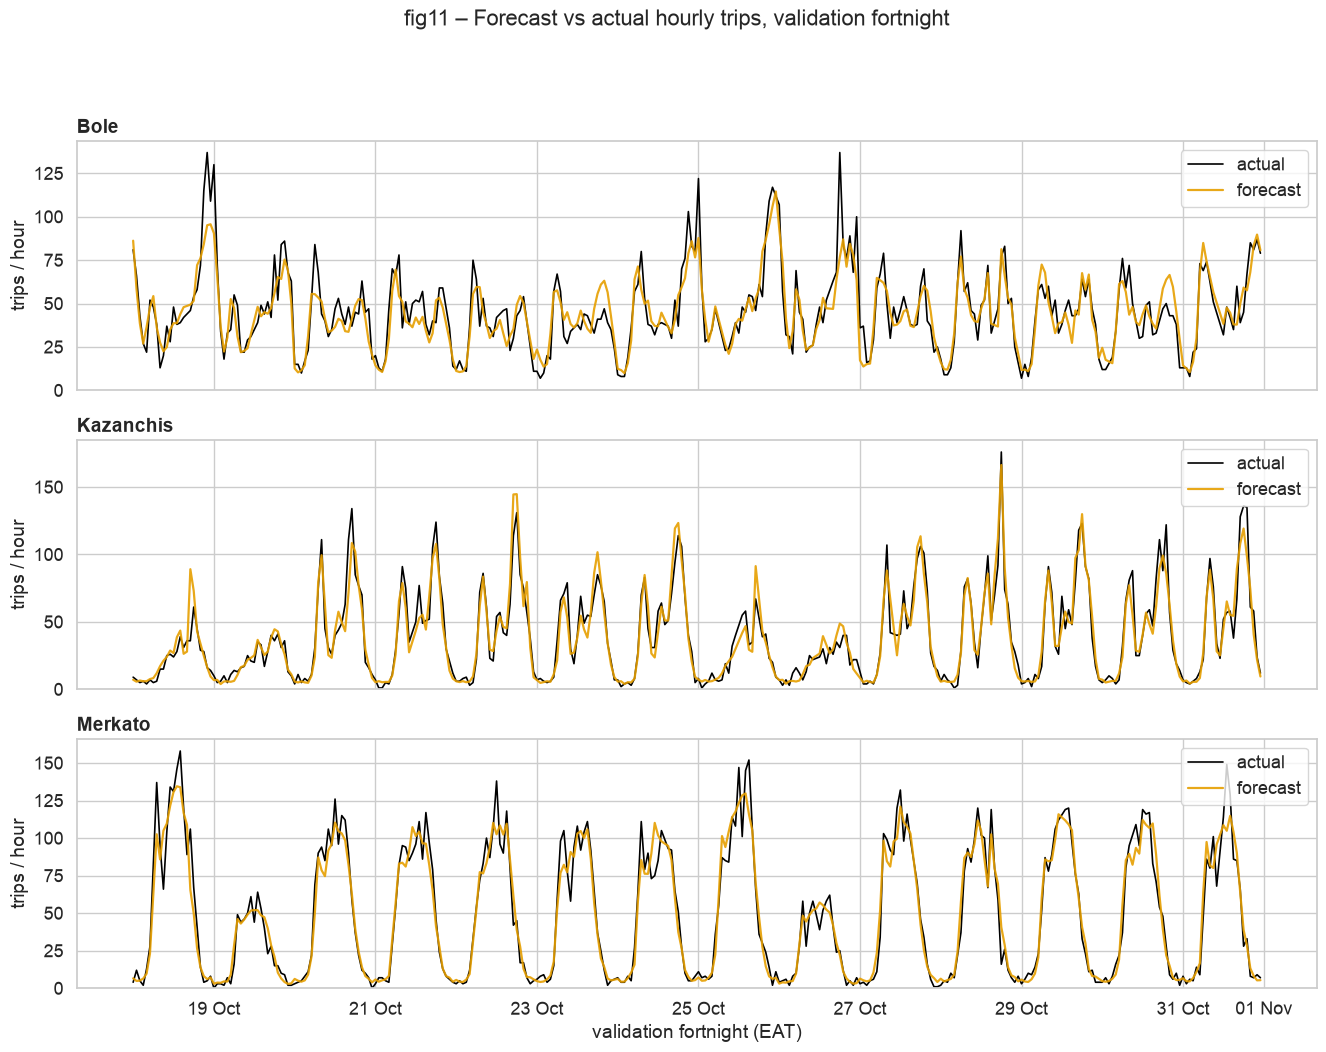

saved fig11_forecast_vs_actual.png


In [12]:
vp = need("val_predictions.csv")
if vp is not None:
    vp["datetime"] = pd.to_datetime(vp["datetime"])
    zs = ["Bole", "Kazanchis", "Merkato"]
    fig, axes = plt.subplots(len(zs), 1, figsize=(16, 11), sharex=True)
    for ax, z in zip(axes, zs):
        s = vp[vp.zone == z].sort_values("datetime")
        ax.plot(s.datetime, s.trips, color=OKABE[7], lw=1.2, label="actual")
        ax.plot(s.datetime, s.predicted, color=OKABE[0], lw=1.6, alpha=0.9, label="forecast")
        ax.set_title(z, loc="left"); ax.set_ylabel("trips / hour"); ax.set_ylim(0); ax.legend(loc="upper right")
    axes[-1].set_xlabel("validation fortnight (EAT)")
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    fig.suptitle("fig11 – Forecast vs actual hourly trips, validation fortnight", y=1.0)
    save(fig, "fig11_forecast_vs_actual.png")

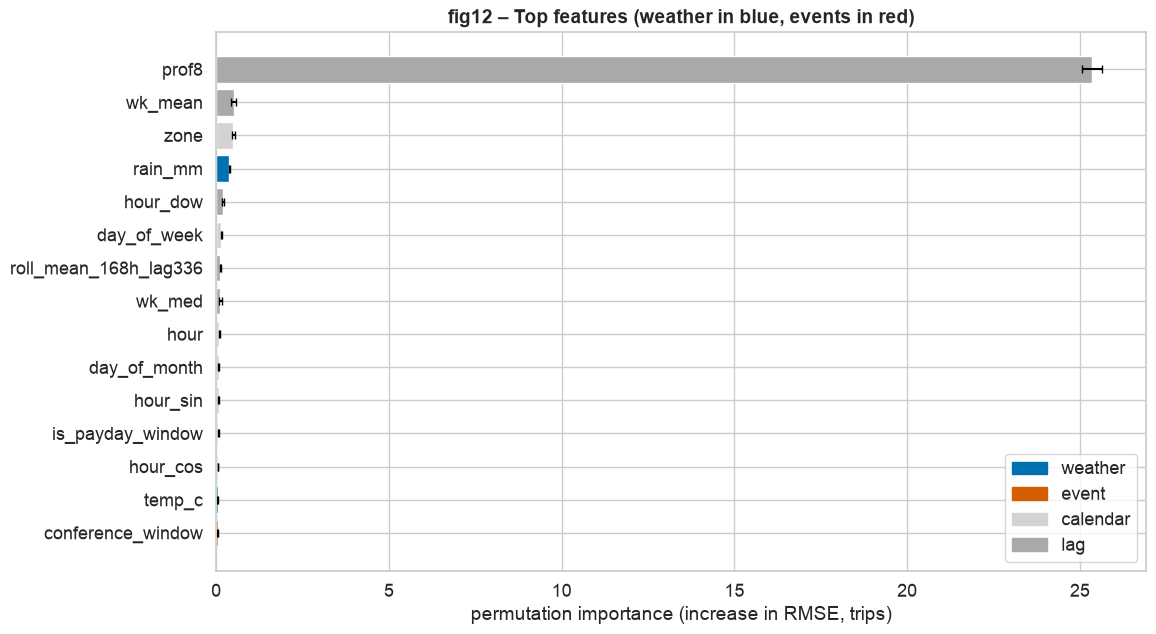

saved fig12_feature_importance.png


In [13]:
fi = need("feature_importance.csv")
if fi is not None:
    fi = fi.sort_values("importance", ascending=False).head(15).iloc[::-1]
    gcol = {"weather": OKABE[4], "event": OKABE[5], "calendar": "lightgrey", "lag": "darkgrey"}
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(fi.feature, fi.importance, xerr=fi.get("importance_std"), color=fi.group.map(gcol).fillna("grey"), capsize=3)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=c, label=g) for g, c in gcol.items()], loc="lower right")
    ax.set_xlabel("permutation importance (increase in RMSE, trips)"); ax.set_xlim(0)
    ax.set_title("fig12 – Top features (weather in blue, events in red)")
    save(fig, "fig12_feature_importance.png")

## Figure captions

In [14]:
captions = {
 "fig01_gaps_and_missingness.png": "Missing/invalid values per column in the three raw tables and a zone × day map of missing trip hours. So what: the gaps are structured — Ayat did not exist before 15 Mar and a 42-hour city-wide outage hit 12–13 May — so they are excluded rather than imputed as zero demand.",
 "fig02_before_after_cleaning.png": "Raw vs cleaned distributions of temperature, rain readings and trips. So what: a July block recorded in °F (60–77), −9999 rain sentinels and trip spikes far beyond driver capacity would each have distorted the model; cleaning removes them without changing the normal range.",
 "fig03_demand_trend_with_holidays.png": "Daily city-wide trips Jan–Oct with 7-day mean, linear trend and public holidays. So what: demand grows ~40% over ten months, so the model needs a trend feature or it will under-forecast November.",
 "fig04_hour_by_weekday_heatmap.png": "Mean trips by hour × weekday city-wide, for Kazanchis and for Bole. So what: one city-wide profile is not enough — business zones empty at weekends while Bole peaks on Friday/Saturday nights, so zone × hour × weekday interactions are essential.",
 "fig05_zone_profiles.png": "Weekday vs weekend hourly profile for the five zone types. So what: CBD/hub zones have 08:00 and 18:00 commuter peaks, residential zones peak at 07:00/19:00, Merkato is a midday plateau and Bole has airport and night peaks.",
 "fig06_weather_timezone_check.png": "Daily temperature curve on the raw vs corrected clock, and rain–demand correlation for each clock shift. So what: the weather file is in UTC; the +3 h correction puts the temperature peak at 15:00 and raises the rain–demand correlation from 0.06 to 0.42.",
 "fig07_rain_effect.png": "Demand ratio vs dry hours by rain class and zone type. So what: rain lifts demand roughly 1.15× (light) to 1.6× (heavy) in every zone type except Merkato, where outdoor shopping falls — the effect is sub-linear and zone-dependent.",
 "fig08_event_study.png": "Demand ratio from −6 h to +6 h around event start for four event types vs the non-event baseline. So what: football and concerts raise demand before and especially after the event, conferences slightly, while road closures suppress it — event windows must extend past the end time.",
 "fig09_holiday_effects.png": "City-wide daily trips on each public holiday relative to the same weekday 1–2 weeks around it. So what: most holidays cut demand by 5–26% (Good Friday, Genna, Eid al-Adha most), while Sunday holidays are near normal — a single holiday flag captures most of the effect.",
 "fig10_model_comparison.png": "Validation RMSE of every model with both baselines marked and rolling-origin error bars. So what: the optimised LightGBM (Poisson loss, 2–5-week lags, 8-week zone×weekday×hour profile) reaches RMSE 8.47 vs 11.30 for seasonal-naive (−25%) and 27.5 for the mean, and stays ahead on every rolling-origin fold (9.21 ± 0.71).",
 "fig11_forecast_vs_actual.png": "Forecast vs actual hourly trips for three contrasting zones over the validation fortnight. So what: the model follows daily peaks and weekend shifts closely in all three zones (MAE 5.85 trips ≈ 4.5 drivers per zone-hour); the largest misses are on the tallest event and rain spikes, which it under-shoots.",
 "fig12_feature_importance.png": "Permutation importance of the top features, with weather and event features highlighted. So what: the 8-week zone×weekday×hour profile dominates (it encodes the zone's normal hour), followed by the multi-week lag mean; rain is the strongest non-history feature, confirming the corrected weather join adds real signal, while individual event flags matter only in the few hours they cover.",
}
existing = [f for f in captions if (FIG / f).exists()]
with open(FIG / "figure_captions.md", "w") as fh:
    fh.write("# Figure captions\n\n")
    for i, (f, c) in enumerate(captions.items(), 1):
        fh.write(f"**{i}. `{f}`** — {c}\n\n")
print(f"figure_captions.md written ({len(captions)} entries); PNGs present: {len(existing)}/12")
for f in captions:
    if (FIG / f).exists():
        from PIL import Image
        print(f"{f:<42} {Image.open(FIG / f).size[0]} px wide")
    else:
        print(f"{f:<42} MISSING")

figure_captions.md written (12 entries); PNGs present: 12/12
fig01_gaps_and_missingness.png             2079 px wide
fig02_before_after_cleaning.png            2103 px wide
fig03_demand_trend_with_holidays.png       2015 px wide
fig04_hour_by_weekday_heatmap.png          2467 px wide
fig05_zone_profiles.png                    2670 px wide
fig06_weather_timezone_check.png           1973 px wide
fig07_rain_effect.png                      1631 px wide
fig08_event_study.png                      1631 px wide
fig09_holiday_effects.png                  2112 px wide
fig10_model_comparison.png                 1952 px wide
fig11_forecast_vs_actual.png               1987 px wide
fig12_feature_importance.png               1717 px wide
